In [ ]:
pip install librosa==0.10.1 soundfile==0.12.1 numpy==1.26.4 pillow==10.4.0 pandas==2.2.2 tqdm==4.66.5

In [1]:
# ===================================================================
# FINAL SCRIPT: Generate Harmonised Spectrograms from Audio
# ===================================================================

# --- Imports ---
import librosa
import numpy as np
import pandas as pd
from PIL import Image
from pathlib import Path
import os
from tqdm.notebook import tqdm

# =============== USER SETTINGS ===============
# Main parent folder containing your audio data subfolders
BASE_IN = Path("/workspaces/cmp9137-advanced-machine-learning/CMP9137 Advanced Machine Learning/Daata_Audio/Audio_files")

# The names of the source folders you want to process
SOURCES = ["Cough_Audio_Coswera", "Cough_Audio_COUGHVID"]

# The names of the label subfolders inside each source folder
LABELS  = ["healthy", "healthy2"]

# Output folder for the new PNGs + metadata.csv
OUT_DIR = Path("/workspaces/cmp9137-advanced-machine-learning/CMP9137 Advanced Machine Learning/Project/Project/Processed_Regenerated")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# =============== SPECTROGRAM PARAMETERS ===============
SR         = 16_000      # sample rate
N_FFT      = 1024        # STFT window length
HOP_LENGTH = 256         # Hop length for STFT
N_MELS     = 128         # Number of Mel bands
FMIN, FMAX = 50, 8000    # Min and max frequencies
TOP_DB     = 80          # Dynamic range in dB
TARGET_HW  = (224, 224)  # Final image size
AUDIO_EXTS = {".wav", ".flac", ".mp3", ".m4a", ".ogg", ".aac"}

# =============== HELPER FUNCTIONS ===============
def load_audio_mono(path, sr=SR):
    """Load mono audio, fixed sample rate, and normalise."""
    y, _ = librosa.load(path, sr=sr, mono=True)
    y = y - np.mean(y) # remove DC offset
    peak = np.max(np.abs(y)) if len(y) else 0.0
    if peak > 0:
        y = y / peak # peak normalise
    y, _ = librosa.effects.trim(y, top_db=25) # trim near-silent edges
    return y

def logmel_spectrogram(y, sr=SR):
    """Compute harmonised log-Mel spectrogram in dB."""
    S = librosa.feature.melspectrogram(
        y=y, sr=sr, n_fft=N_FFT, hop_length=HOP_LENGTH,
        n_mels=N_MELS, fmin=FMIN, fmax=FMAX, power=2.0
    )
    S_db = librosa.power_to_db(S, ref=np.max)
    S_db = np.clip(S_db, -TOP_DB, 0) # clip to fixed dynamic range
    S01 = (S_db + TOP_DB) / TOP_DB # normalise to [0, 1]
    return S01

def to_png_grayscale(arr_01, size=TARGET_HW):
    """Convert [0,1] spectrogram to 8-bit grayscale PNG."""
    im = (arr_01 * 255.0).round().astype(np.uint8)
    img = Image.fromarray(im, mode="L")
    img = img.resize(size, Image.BICUBIC)
    return img

# =============== MAIN PROCESSING LOOP ===============
rows = []
total_audio = 0

print(f"Scanning sources in: {BASE_IN}")
for source in SOURCES:
    for label in LABELS:
        in_dir = BASE_IN / source / label
        if not in_dir.exists():
            print(f"⚠️  Missing folder (skipped): {in_dir}")
            continue

        out_dir = OUT_DIR / source / label
        out_dir.mkdir(parents=True, exist_ok=True)

        files = [f for f in in_dir.rglob("*") if f.suffix.lower() in AUDIO_EXTS]
        if not files:
            print(f"⚠️  No audio found in: {in_dir}")
            continue

        print(f"→ Processing {source}/{label}: {len(files)} files")
        for f in tqdm(files, desc=f"{source}/{label}"):
            try:
                y = load_audio_mono(f)
                if y.size == 0:
                    continue
                S01 = logmel_spectrogram(y)
                img = to_png_grayscale(S01, size=TARGET_HW)

                base = f.stem.replace(" ", "_")
                out_path = out_dir / f"{base}.png"
                img.save(out_path)

                rows.append({
                    "filepath": str(out_path.resolve()),
                    "label": label,
                    "source": source,
                    "orig_audio": str(f.resolve())
                })
                total_audio += 1
            except Exception as e:
                print(f"   ⚠️  Failed on {f}: {e}")

# Save metadata
if rows:
    df = pd.DataFrame(rows)
    df.to_csv(OUT_DIR / "metadata.csv", index=False)
    print(f"\n✅ Done. Saved {len(rows)} spectrograms.")
    print(f"📄 Metadata: {OUT_DIR / 'metadata.csv'}")
else:
    print("❌ No files processed. Check folder paths and extensions.")

Scanning sources in: /workspaces/cmp9137-advanced-machine-learning/CMP9137 Advanced Machine Learning/Daata_Audio/Audio_files
→ Processing Cough_Audio_Coswera/healthy: 2865 files


Cough_Audio_Coswera/healthy:   0%|          | 0/2865 [00:00<?, ?it/s]

/usr/local/lib/python3.11/dist-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.11/dist-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)


⚠️  Missing folder (skipped): /workspaces/cmp9137-advanced-machine-learning/CMP9137 Advanced Machine Learning/Daata_Audio/Audio_files/Cough_Audio_Coswera/healthy2
⚠️  Missing folder (skipped): /workspaces/cmp9137-advanced-machine-learning/CMP9137 Advanced Machine Learning/Daata_Audio/Audio_files/Cough_Audio_COUGHVID/healthy
→ Processing Cough_Audio_COUGHVID/healthy2: 1659 files


Cough_Audio_COUGHVID/healthy2:   0%|          | 0/1659 [00:00<?, ?it/s]

   ⚠️  Failed on /workspaces/cmp9137-advanced-machine-learning/CMP9137 Advanced Machine Learning/Daata_Audio/Audio_files/Cough_Audio_COUGHVID/healthy2/00098cdb-4da1-4aa7-825a-4f1b9abc214b.wav: 


/tmp/ipykernel_9876/2495593272.py:41: UserWarning: PySoundFile failed. Trying audioread instead.
  y, _ = librosa.load(path, sr=sr, mono=True)
/usr/local/lib/python3.11/dist-packages/librosa/core/audio.py:183: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


   ⚠️  Failed on /workspaces/cmp9137-advanced-machine-learning/CMP9137 Advanced Machine Learning/Daata_Audio/Audio_files/Cough_Audio_COUGHVID/healthy2/007089d2-ed48-4464-b981-66fc66a6c121.wav: 
   ⚠️  Failed on /workspaces/cmp9137-advanced-machine-learning/CMP9137 Advanced Machine Learning/Daata_Audio/Audio_files/Cough_Audio_COUGHVID/healthy2/00bca802-462d-403c-956d-5c92f3f886c3.wav: 
   ⚠️  Failed on /workspaces/cmp9137-advanced-machine-learning/CMP9137 Advanced Machine Learning/Daata_Audio/Audio_files/Cough_Audio_COUGHVID/healthy2/00eb562b-7e14-4981-8521-0194253470f0.wav: 
   ⚠️  Failed on /workspaces/cmp9137-advanced-machine-learning/CMP9137 Advanced Machine Learning/Daata_Audio/Audio_files/Cough_Audio_COUGHVID/healthy2/00eeef06-9ab0-45d8-8ddf-5fbc54b96dec.wav: 
   ⚠️  Failed on /workspaces/cmp9137-advanced-machine-learning/CMP9137 Advanced Machine Learning/Daata_Audio/Audio_files/Cough_Audio_COUGHVID/healthy2/00f41aaf-b05b-4594-8769-fed636fad323.wav: 
   ⚠️  Failed on /workspaces/c

/usr/local/lib/python3.11/dist-packages/librosa/core/spectrum.py:257: UserWarning: n_fft=1024 is too large for input signal of length=683
  warnings.warn(


   ⚠️  Failed on /workspaces/cmp9137-advanced-machine-learning/CMP9137 Advanced Machine Learning/Daata_Audio/Audio_files/Cough_Audio_COUGHVID/healthy2/cf280e42-b806-44a3-a2de-9e20690dedd4.wav: 
   ⚠️  Failed on /workspaces/cmp9137-advanced-machine-learning/CMP9137 Advanced Machine Learning/Daata_Audio/Audio_files/Cough_Audio_COUGHVID/healthy2/cf57ed69-a8b9-4518-b817-cd91b872c5ec.wav: 
   ⚠️  Failed on /workspaces/cmp9137-advanced-machine-learning/CMP9137 Advanced Machine Learning/Daata_Audio/Audio_files/Cough_Audio_COUGHVID/healthy2/cf6dd28a-00c3-4e04-a0ec-2a9b27a7f10f.wav: 
   ⚠️  Failed on /workspaces/cmp9137-advanced-machine-learning/CMP9137 Advanced Machine Learning/Daata_Audio/Audio_files/Cough_Audio_COUGHVID/healthy2/cf9a5fb6-823d-48b8-8fb1-572968e5cd1a.wav: 
   ⚠️  Failed on /workspaces/cmp9137-advanced-machine-learning/CMP9137 Advanced Machine Learning/Daata_Audio/Audio_files/Cough_Audio_COUGHVID/healthy2/cff0465e-daab-4bcf-9fe3-57122111e07b.wav: 
   ⚠️  Failed on /workspaces/c

In [2]:
# ===================================================================
# CELL: Calculate Quality Scores for REGENERATED Spectrograms
# ===================================================================
import pandas as pd
from pathlib import Path
import cv2
from tqdm.notebook import tqdm
import numpy as np

# 1. Load the metadata for the REGENERATED dataset
METADATA_CSV = "/workspaces/cmp9137-advanced-machine-learning/CMP9137 Advanced Machine Learning/Project/Project/Processed_Regenerated/metadata.csv" 
try:
    metadata = pd.read_csv(METADATA_CSV, engine='python')

    quality_scores = []
    
    print("Calculating quality scores for the regenerated dataset...")
    # 2. Loop through each image and calculate its mean intensity
    for filepath in tqdm(metadata['filepath'], desc="Scoring images"):
        try:
            img = cv2.imread(filepath, cv2.IMREAD_GRAYSCALE)
            if img is not None:
                quality_scores.append(np.mean(img))
            else:
                quality_scores.append(0)
        except Exception as e:
            print(f"Error processing {filepath}: {e}")
            quality_scores.append(0)

    # 3. Add the scores as a new column to the DataFrame
    metadata['quality_score'] = quality_scores

    # 4. Display the first few rows with the new scores
    print("\n--- Regenerated Metadata with Quality Scores ---")
    display(metadata.head())

    # 5. Display some basic statistics about the scores
    print("\n--- Score Statistics ---")
    display(metadata['quality_score'].describe())

except FileNotFoundError:
    print(f"❌ ERROR: Could not find the metadata file at: {METADATA_CSV}")
    print("Please make sure the path is correct.")

Calculating quality scores for the regenerated dataset...


Scoring images:   0%|          | 0/3646 [00:00<?, ?it/s]


--- Regenerated Metadata with Quality Scores ---


,filepath,label,source,orig_audio,quality_score
0,/workspaces/cmp9137-advanced-machine-learning/...,healthy,Cough_Audio_Coswera,/workspaces/cmp9137-advanced-machine-learning/...,51.191127
1,/workspaces/cmp9137-advanced-machine-learning/...,healthy,Cough_Audio_Coswera,/workspaces/cmp9137-advanced-machine-learning/...,48.078783
2,/workspaces/cmp9137-advanced-machine-learning/...,healthy,Cough_Audio_Coswera,/workspaces/cmp9137-advanced-machine-learning/...,63.281808
3,/workspaces/cmp9137-advanced-machine-learning/...,healthy,Cough_Audio_Coswera,/workspaces/cmp9137-advanced-machine-learning/...,83.081393
4,/workspaces/cmp9137-advanced-machine-learning/...,healthy,Cough_Audio_Coswera,/workspaces/cmp9137-advanced-machine-learning/...,76.568300



--- Score Statistics ---


count    3646.000000
mean       72.405022
std        33.322026
min        12.303452
25%        52.037204
50%        67.173270
75%        85.361248
max       255.000000
Name: quality_score, dtype: float64

In [10]:
# ===================================================================
# CELL: Calculate Quality Scores and Save to NEW File
# ===================================================================
import pandas as pd
from pathlib import Path
import cv2
from tqdm.notebook import tqdm
import numpy as np

# 1. Path to the metadata from your spectrogram generation
METADATA_PATH = "/workspaces/cmp9137-advanced-machine-learning/CMP9137 Advanced Machine Learning/Project/Project/Processed_Regenerated/metadata.csv"

# 2. Define the path for the NEW metadata file
NEW_METADATA_PATH = "/workspaces/cmp9137-advanced-machine-learning/CMP9137 Advanced Machine Learning/Project/Project/Processed_Regenerated/metadata_with_scores.csv"

try:
    metadata = pd.read_csv(METADATA_PATH, engine='python')
    
    quality_scores = []
    
    print("Calculating quality scores...")
    for filepath in tqdm(metadata['filepath'], desc="Scoring images"):
        img = cv2.imread(filepath, cv2.IMREAD_GRAYSCALE)
        if img is not None:
            quality_scores.append(np.mean(img))
        else:
            quality_scores.append(0)
    
    # 3. Add the new column
    metadata['quality_score'] = quality_scores
    
    # 4. Save the updated dataframe to the NEW file
    metadata.to_csv(NEW_METADATA_PATH, index=False)
    
    print(f"\n✅ Successfully added 'quality_score' column.")
    print(f"📄 New metadata file saved to: {NEW_METADATA_PATH}")
    print("\n--- Regenerated Metadata with Quality Scores ---")
    display(metadata.head())
    print("\n--- Score Statistics ---")
    display(metadata['quality_score'].describe())

except FileNotFoundError:
    print(f"❌ ERROR: Could not find the metadata file at: {METADATA_PATH}")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

Calculating quality scores...


Scoring images:   0%|          | 0/3646 [00:00<?, ?it/s]


✅ Successfully added 'quality_score' column.
📄 New metadata file saved to: /workspaces/cmp9137-advanced-machine-learning/CMP9137 Advanced Machine Learning/Project/Project/Processed_Regenerated/metadata_with_scores.csv

--- Regenerated Metadata with Quality Scores ---


,filepath,label,source,orig_audio,quality_score
0,/workspaces/cmp9137-advanced-machine-learning/...,healthy,Cough_Audio_Coswera,/workspaces/cmp9137-advanced-machine-learning/...,51.191127
1,/workspaces/cmp9137-advanced-machine-learning/...,healthy,Cough_Audio_Coswera,/workspaces/cmp9137-advanced-machine-learning/...,48.078783
2,/workspaces/cmp9137-advanced-machine-learning/...,healthy,Cough_Audio_Coswera,/workspaces/cmp9137-advanced-machine-learning/...,63.281808
3,/workspaces/cmp9137-advanced-machine-learning/...,healthy,Cough_Audio_Coswera,/workspaces/cmp9137-advanced-machine-learning/...,83.081393
4,/workspaces/cmp9137-advanced-machine-learning/...,healthy,Cough_Audio_Coswera,/workspaces/cmp9137-advanced-machine-learning/...,76.568300



--- Score Statistics ---


count    3646.000000
mean       72.405022
std        33.322026
min        12.303452
25%        52.037204
50%        67.173270
75%        85.361248
max       255.000000
Name: quality_score, dtype: float64

In [11]:
# ===================================================================
# CELL: Filter Regenerated Data for Quality
# ===================================================================
import pandas as pd
from pathlib import Path

# 1. Path to the metadata with quality scores we just created
METADATA_WITH_SCORES = Path("/workspaces/cmp9137-advanced-machine-learning/CMP9137 Advanced Machine Learning/Project/Project/Processed_Regenerated/metadata_with_scores.csv")

# 2. Path for the new, filtered metadata file
FILTERED_METADATA_PATH = Path("/workspaces/cmp9137-advanced-machine-learning/CMP9137 Advanced Machine Learning/Project/Project/Processed_Regenerated/metadata_filtered.csv")

# 3. The quality threshold we decided on
QUALITY_THRESHOLD = 20

try:
    df = pd.read_csv(METADATA_WITH_SCORES, engine='python')
    
    # Apply the filter
    df_filtered = df[df['quality_score'] >= QUALITY_THRESHOLD].copy()
    
    # Save the new DataFrame
    df_filtered.to_csv(FILTERED_METADATA_PATH, index=False)
    
    print(f"Original count: {len(df)}")
    print(f"Count after filtering (quality >= {QUALITY_THRESHOLD}): {len(df_filtered)}")
    print(f"✅ Filtered metadata saved to: {FILTERED_METADATA_PATH}")

except FileNotFoundError:
    print(f"❌ ERROR: Could not find the metadata file at: {METADATA_WITH_SCORES}")

Original count: 3646
Count after filtering (quality >= 20): 3629
✅ Filtered metadata saved to: /workspaces/cmp9137-advanced-machine-learning/CMP9137 Advanced Machine Learning/Project/Project/Processed_Regenerated/metadata_filtered.csv


In [7]:
!head -n 1 "/workspaces/cmp9137-advanced-machine-learning/CMP9137 Advanced Machine Learning/Project/Project/Processed_Regenerated/metadata.csv"

filepath,label,source,orig_audio


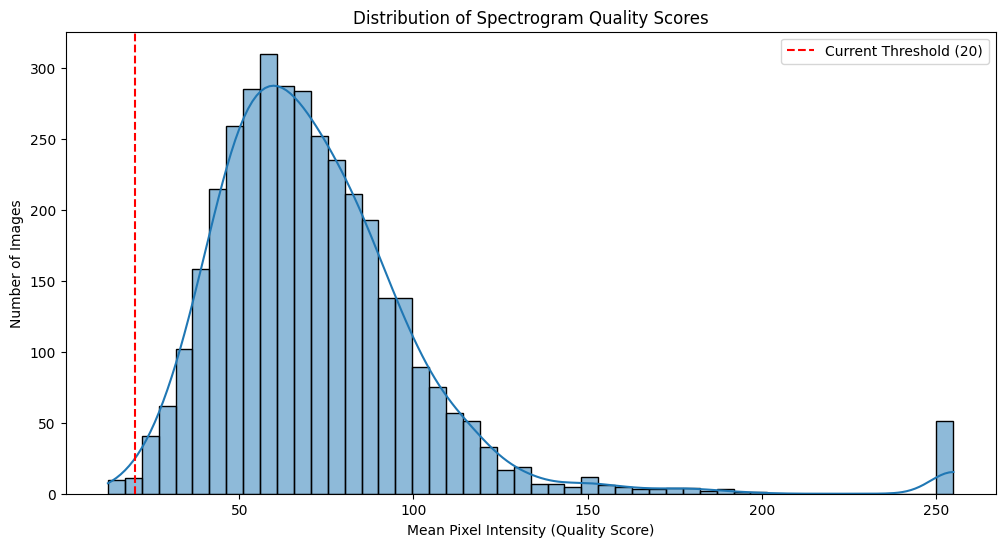

In [14]:
# ===================================================================
# CELL: Visualize Quality Score Distribution
# ===================================================================
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure the 'metadata' DataFrame with the 'quality_score' column is loaded

plt.figure(figsize=(12, 6))
sns.histplot(metadata['quality_score'], bins=50, kde=True)
plt.title('Distribution of Spectrogram Quality Scores')
plt.xlabel('Mean Pixel Intensity (Quality Score)')
plt.ylabel('Number of Images')

# Add a vertical line for our current threshold of 20 for reference
plt.axvline(x=20, color='r', linestyle='--', label='Current Threshold (20)')
plt.legend()

plt.show()

In [13]:
pip install seaborn


[notice] A new release of pip is available: 24.3.1 -> 25.2
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [18]:
# ===================================================================
# CELL: Apply Two-Sided Quality Filter
# ===================================================================
import pandas as pd
from pathlib import Path

# 1. Path to the metadata with quality scores
METADATA_WITH_SCORES = Path("/workspaces/cmp9137-advanced-machine-learning/CMP9137 Advanced Machine Learning/Project/Project/Processed_Regenerated/metadata_with_scores.csv")

# 2. Path for the new, final filtered metadata file
FILTERED_METADATA_PATH = Path("/workspaces/cmp9137-advanced-machine-learning/CMP9137 Advanced Machine Learning/Project/Project/Processed_Regenerated/metadata_final_filtered.csv")

# 3. Your new quality thresholds
LOWER_THRESHOLD = 25
UPPER_THRESHOLD = 240

try:
    df = pd.read_csv(METADATA_WITH_SCORES, engine='python')
    original_count = len(df)
    
    # Apply the lower bound filter
    df_low_filtered = df[df['quality_score'] >= LOWER_THRESHOLD].copy()
    count_after_low = len(df_low_filtered)
    
    # Apply the upper bound filter
    df_final_filtered = df_low_filtered[df_low_filtered['quality_score'] <= UPPER_THRESHOLD].copy()
    count_after_high = len(df_final_filtered)
    
    # Save the new DataFrame
    df_final_filtered.to_csv(FILTERED_METADATA_PATH, index=False)
    
    # --- Report Results ---
    print(f"Original count: {original_count}")
    print(f"Removed by low filter (< {LOWER_THRESHOLD}): {original_count - count_after_low}")
    print(f"Removed by high filter (> {UPPER_THRESHOLD}): {count_after_low - count_after_high}")
    print("---------------------------------")
    print(f"Final count: {len(df_final_filtered)}")
    print(f"✅ Final filtered metadata saved to: {FILTERED_METADATA_PATH}")

except FileNotFoundError:
    print(f"❌ ERROR: Could not find the metadata file at: {METADATA_WITH_SCORES}")
except KeyError:
    print(f"❌ ERROR: The file doesn't have a 'quality_score' column. Please run the scoring script first.")

Original count: 3646
Removed by low filter (< 25): 47
Removed by high filter (> 240): 51
---------------------------------
Final count: 3548
✅ Final filtered metadata saved to: /workspaces/cmp9137-advanced-machine-learning/CMP9137 Advanced Machine Learning/Project/Project/Processed_Regenerated/metadata_final_filtered.csv


In [20]:
from collections import Counter
import os, pandas as pd
from PIL import Image

BASE = "/workspaces/cmp9137-advanced-machine-learning/CMP9137 Advanced Machine Learning/Project/Project/Processed_Regenerated"

# Try these in order; the first that exists will be used
CANDIDATES = [
    "metadata_healthy_final_filtered.csv",
    "metadata_final_filtered.csv",
    "metadata_filtered.csv",
    "metadata.csv",
]

csv_path = None
for name in CANDIDATES:
    path = os.path.join(BASE, name)
    if os.path.exists(path):
        csv_path = path
        break

if csv_path is None:
    raise FileNotFoundError(
        "Could not find any metadata CSV. Expected one of: "
        + ", ".join(os.path.join(BASE, n) for n in CANDIDATES)
    )

print("Using CSV:", csv_path)
df = pd.read_csv(csv_path)

# Keep only healthy rows if the label column exists
if "label" in df.columns:
    df = df[df["label"].astype(str).str.lower() == "healthy"].copy()

# Collect a sample of paths that exist
paths = [p for p in df["filepath"].dropna().tolist()
         if isinstance(p, str) and os.path.exists(p)]

if not paths:
    raise FileNotFoundError("No existing healthy filepaths found in the chosen CSV.")

# Inspect a small sample (adjust N if you want)
N = min(200, len(paths))
sizes, modes = [], []
for p in paths[:N]:
    with Image.open(p) as im:
        sizes.append(im.size)   # (W, H)
        modes.append(im.mode)   # 'L' means grayscale

from pprint import pprint
print("\nTop sizes (W,H):")
pprint(Counter(sizes).most_common(5))
print("\nImage modes:")
pprint(Counter(modes).most_common())

TARGET_SIZE = Counter(sizes).most_common(1)[0][0]
print("\n>>> TARGET_SIZE to match =", TARGET_SIZE)


Using CSV: /workspaces/cmp9137-advanced-machine-learning/CMP9137 Advanced Machine Learning/Project/Project/Processed_Regenerated/metadata_final_filtered.csv

Top sizes (W,H):
[((224, 224), 200)]

Image modes:
[('L', 200)]

>>> TARGET_SIZE to match = (224, 224)


In [21]:
# harmonize_existing_spects.py
import os, glob
from PIL import Image
import numpy as np
import pandas as pd

# Your folders
CANCER_DIR = "/workspaces/cmp9137-advanced-machine-learning/CMP9137 Advanced Machine Learning/Project/Project/Processed/Processed/cancer"
KAGGLE_DIR = "/workspaces/cmp9137-advanced-machine-learning/CMP9137 Advanced Machine Learning/Project/Project/Processed/Processed/healthy_kaggle"
KAGGLE_LABEL = "healthy"   # inferred from folder name

TARGET_SIZE = (224, 224)   # must match healthy set
OUT_BASE = "/workspaces/cmp9137-advanced-machine-learning/CMP9137 Advanced Machine Learning/Project/Project/Processed_Regenerated/harmonized_additions"
os.makedirs(OUT_BASE, exist_ok=True)

def scan(dirpath):
    files = []
    for ext in ("*.png","*.jpg","*.jpeg","*.bmp","*.tif","*.tiff","*.webp"):
        files += glob.glob(os.path.join(dirpath, "**", ext), recursive=True)
    return sorted(files)

def pad_to_square(img: Image.Image, fill=0):
    w, h = img.size
    if w == h: return img
    s = max(w, h)
    canvas = Image.new("L", (s, s), color=fill)  # black padding
    canvas.paste(img, ((s - w) // 2, (s - h) // 2))
    return canvas

def harmonize_one(in_path, out_dir):
    try:
        im = Image.open(in_path).convert("L")                 # grayscale
        im = pad_to_square(im, fill=0)                        # letterbox to square
        im = im.resize(TARGET_SIZE, Image.BILINEAR)           # resize to 224×224
        os.makedirs(out_dir, exist_ok=True)
        out_path = os.path.join(out_dir, os.path.basename(in_path))
        im.save(out_path)                                     # uint8 0–255
        q = float(np.array(im, dtype=np.uint8).mean())        # mean intensity
        return out_path, q, None
    except Exception as e:
        return None, None, str(e)

def process_block(files, label, source, subfolder):
    out_dir = os.path.join(OUT_BASE, subfolder)
    rows, n_ok, n_fail = [], 0, 0
    for f in files:
        out_path, q, err = harmonize_one(f, out_dir)
        if out_path is not None:
            rows.append({"filepath": out_path, "label": label, "source": source,
                         "orig_image": f, "quality_score": q})
            n_ok += 1
        else:
            n_fail += 1
    return pd.DataFrame(rows), n_ok, n_fail

# Run
cancer_files = scan(CANCER_DIR)
kaggle_files = scan(KAGGLE_DIR)

df_c, ok_c, fail_c = process_block(cancer_files, "cancer",      "kaggle_cancer_raw",  "cancer")
df_k, ok_k, fail_k = process_block(kaggle_files, KAGGLE_LABEL,  "kaggle_normal_raw",  "kaggle")

df_all = pd.concat([df_c, df_k], ignore_index=True)
meta_out = os.path.join(OUT_BASE, "metadata_additions_harmonized.csv")
df_all.to_csv(meta_out, index=False)

print("✅ Saved:", meta_out)
print(f"Cancer: {ok_c} ok, {fail_c} failed")
print(f"Kaggle: {ok_k} ok, {fail_k} failed")
print("Totals:", len(df_all))
print("\nLabel counts:\n", df_all["label"].value_counts())
print("\nSource counts:\n", df_all["source"].value_counts())


✅ Saved: /workspaces/cmp9137-advanced-machine-learning/CMP9137 Advanced Machine Learning/Project/Project/Processed_Regenerated/harmonized_additions/metadata_additions_harmonized.csv
Cancer: 30 ok, 0 failed
Kaggle: 24 ok, 0 failed
Totals: 54

Label counts:
 label
cancer     30
healthy    24
Name: count, dtype: int64

Source counts:
 source
kaggle_cancer_raw    30
kaggle_normal_raw    24
Name: count, dtype: int64


In [22]:
# step_merge_additions.py
import os, pandas as pd

BASE = "/workspaces/cmp9137-advanced-machine-learning/CMP9137 Advanced Machine Learning/Project/Project/Processed_Regenerated"
healthy_csv = f"{BASE}/metadata_final_filtered.csv"                       # your cleaned healthy set
add_csv     = f"{BASE}/harmonized_additions/metadata_additions_harmonized.csv"
out_csv     = f"{BASE}/metadata_master_final.csv"

df_h   = pd.read_csv(healthy_csv)
df_add = pd.read_csv(add_csv)

# Normalise label/source text just in case
for df in (df_h, df_add):
    if "label" in df.columns:
        df["label"] = df["label"].astype(str).str.lower().str.strip()
    if "source" in df.columns:
        df["source"] = df["source"].astype(str).str.strip()

# Merge and drop duplicates by filepath
df_all = pd.concat([df_h, df_add], ignore_index=True)
df_all = df_all.drop_duplicates(subset=["filepath"]).reset_index(drop=True)

df_all.to_csv(out_csv, index=False)

print(f"✅ Saved master metadata: {out_csv}")
print("Counts by label:\n", df_all["label"].value_counts(dropna=False))
if "source" in df_all.columns:
    print("\nCounts by source:\n", df_all["source"].value_counts().head(10))
print("\nTotal files:", len(df_all))


✅ Saved master metadata: /workspaces/cmp9137-advanced-machine-learning/CMP9137 Advanced Machine Learning/Project/Project/Processed_Regenerated/metadata_master_final.csv
Counts by label:
 label
healthy     2757
healthy2     815
cancer        30
Name: count, dtype: int64

Counts by source:
 source
Cough_Audio_Coswera     2733
Cough_Audio_COUGHVID     815
kaggle_cancer_raw         30
kaggle_normal_raw         24
Name: count, dtype: int64

Total files: 3602


In [26]:
import os, pandas as pd

BASE = "/workspaces/cmp9137-advanced-machine-learning/CMP9137 Advanced Machine Learning/Project/Project/Processed_Regenerated"
in_csv  = f"{BASE}/metadata_master_final.csv"
out_csv = f"{BASE}/metadata_master_final_norm.csv"

df = pd.read_csv(in_csv)

# Clean text
df["label"]  = df["label"].astype(str).str.lower().str.strip()
df["source"] = df["source"].astype(str).str.strip()

# Unify label variants
df["label"] = df["label"].replace({"healthy2": "healthy", "healthy ": "healthy"})

df.to_csv(out_csv, index=False)

print(f"✅ Saved: {out_csv}")
print("Counts by label:\n", df["label"].value_counts(dropna=False))
print("\nCounts by source:\n", df["source"].value_counts().head(10))
print("\nTotal files:", len(df))


✅ Saved: /workspaces/cmp9137-advanced-machine-learning/CMP9137 Advanced Machine Learning/Project/Project/Processed_Regenerated/metadata_master_final_norm.csv
Counts by label:
 label
healthy    3572
cancer       30
Name: count, dtype: int64

Counts by source:
 source
Cough_Audio_Coswera     2733
Cough_Audio_COUGHVID     815
kaggle_cancer_raw         30
kaggle_normal_raw         24
Name: count, dtype: int64

Total files: 3602


In [28]:
import os, numpy as np, pandas as pd
from PIL import Image

BASE = "/workspaces/cmp9137-advanced-machine-learning/CMP9137 Advanced Machine Learning/Project/Project/Processed_Regenerated"
in_csv  = f"{BASE}/metadata_master_final_norm.csv"     # your current master
out_csv = f"{BASE}/metadata_master_final_norm_q.csv"   # master + clean quality_score

df = pd.read_csv(in_csv)

# Ensure column exists and force to numeric (turns '[]', '' → NaN)
if "quality_score" not in df.columns:
    df["quality_score"] = np.nan
df["quality_score"] = pd.to_numeric(df["quality_score"], errors="coerce")

def mean_intensity(path):
    try:
        if not isinstance(path, str) or not os.path.exists(path):
            return np.nan
        with Image.open(path).convert("L") as im:
            arr = np.array(im, dtype=np.uint8)
            return float(arr.mean()) if arr.size else np.nan
    except Exception:
        return np.nan

# Recompute only where missing
mask_missing = df["quality_score"].isna()
print(f"Rows missing quality_score before: {mask_missing.sum()} / {len(df)}")

df.loc[mask_missing, "quality_score"] = df.loc[mask_missing, "filepath"].apply(mean_intensity)

# Final coercion + report
df["quality_score"] = pd.to_numeric(df["quality_score"], errors="coerce")
missing_after = df["quality_score"].isna().sum()
print(f"Rows still missing after recompute: {missing_after}")

df.to_csv(out_csv, index=False)
print(f"✅ Saved with quality scores: {out_csv}")


Rows missing quality_score before: 0 / 3602
Rows still missing after recompute: 0
✅ Saved with quality scores: /workspaces/cmp9137-advanced-machine-learning/CMP9137 Advanced Machine Learning/Project/Project/Processed_Regenerated/metadata_master_final_norm_q.csv


/tmp/ipykernel_14819/722029605.py:29: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[]' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.loc[mask_missing, "quality_score"] = df.loc[mask_missing, "filepath"].apply(mean_intensity)


In [29]:
import os, shutil, textwrap

PROJ   = "/workspaces/cmp9137-advanced-machine-learning/CMP9137 Advanced Machine Learning/Project/Project"
BASE   = f"{PROJ}/Processed_Regenerated"
MASTER = f"{PROJ}/Final_Master"

src_csv = f"{BASE}/metadata_master_final_norm_q.csv"  # has labels normalised + quality_score
os.makedirs(os.path.join(MASTER, "metadata"), exist_ok=True)
os.makedirs(os.path.join(MASTER, "images"),   exist_ok=True)

dst_csv = os.path.join(MASTER, "metadata", "master_metadata.csv")
shutil.copy2(src_csv, dst_csv)

readme = os.path.join(MASTER, "README.txt")
with open(readme, "w") as f:
    f.write(textwrap.dedent("""
    Final Master Dataset
    --------------------
    - metadata/master_metadata.csv : canonical metadata (labels unified, quality_score present)
    - images/                      : (empty for now) we'll add symlinks here next

    Target image format: 224×224, grayscale ('L')
    QC thresholds to use later: low < 25, high > 240
    """).strip())

print("✅ Created:", MASTER)
print("📄 Copied metadata to:", dst_csv)
print("📝 README:", readme)


✅ Created: /workspaces/cmp9137-advanced-machine-learning/CMP9137 Advanced Machine Learning/Project/Project/Final_Master
📄 Copied metadata to: /workspaces/cmp9137-advanced-machine-learning/CMP9137 Advanced Machine Learning/Project/Project/Final_Master/metadata/master_metadata.csv
📝 README: /workspaces/cmp9137-advanced-machine-learning/CMP9137 Advanced Machine Learning/Project/Project/Final_Master/README.txt


In [30]:
# step_populate_master_images.py
import os, shutil, pandas as pd

PROJ   = "/workspaces/cmp9137-advanced-machine-learning/CMP9137 Advanced Machine Learning/Project/Project"
MASTER = f"{PROJ}/Final_Master"
META   = f"{MASTER}/metadata/master_metadata.csv"
IMGROOT= f"{MASTER}/images"

df = pd.read_csv(META)

# minimal hygiene
assert "filepath" in df.columns, "metadata must have 'filepath'"
if "label" not in df.columns: df["label"] = "unknown"
if "source" not in df.columns: df["source"] = "unknown"

n_ok = n_exists = n_missing = n_copied = 0
for _, row in df.iterrows():
    src = row["filepath"]
    if not isinstance(src, str) or not os.path.exists(src):
        n_missing += 1
        continue

    label  = str(row["label"]).strip().lower()
    source = str(row["source"]).strip()
    out_dir = os.path.join(IMGROOT, label, source)
    os.makedirs(out_dir, exist_ok=True)

    dst = os.path.join(out_dir, os.path.basename(src))
    if os.path.lexists(dst):
        n_exists += 1
        continue

    try:
        os.symlink(src, dst)     # preferred: no extra disk
        n_ok += 1
    except OSError:
        shutil.copy2(src, dst)   # fallback if symlinks not allowed
        n_copied += 1

print("✅ Done populating images")
print(f"Symlinks created: {n_ok}")
print(f"Copied (fallback): {n_copied}")
print(f"Already existed:   {n_exists}")
print(f"Missing sources:   {n_missing}")
print(f"Root folder:       {IMGROOT}")


✅ Done populating images
Symlinks created: 3602
Copied (fallback): 0
Already existed:   0
Missing sources:   0
Root folder:       /workspaces/cmp9137-advanced-machine-learning/CMP9137 Advanced Machine Learning/Project/Project/Final_Master/images


In [31]:
from collections import Counter
import os, random, pandas as pd
from PIL import Image
import numpy as np

MASTER = "/workspaces/cmp9137-advanced-machine-learning/CMP9137 Advanced Machine Learning/Project/Project/Final_Master"
CSV    = f"{MASTER}/metadata/master_metadata.csv"

df = pd.read_csv(CSV)

# sample a subset for speed; bump N to scan more/all if you like
N = min(256, len(df))
paths = df["filepath"].dropna().tolist()
random.seed(0); random.shuffle(paths)
paths = [p for p in paths if isinstance(p, str) and os.path.exists(p)][:N]

sizes, modes, bad = [], [], []
for p in paths:
    try:
        with Image.open(p) as im:
            sizes.append(im.size)
            modes.append(im.mode)
            if not (im.mode == "L" and im.size == (224,224)):
                bad.append((p, im.mode, im.size))
    except Exception as e:
        bad.append((p, f"ERR:{type(e).__name__}", None))

print("Sample size:", len(paths))
print("Top image sizes:", Counter(sizes).most_common(3))
print("Top image modes:", Counter(modes).most_common(3))
print("Mismatches in sample:", len(bad))
if bad[:5]:
    print("Example mismatches:")
    for b in bad[:5]: print(" -", b)

# Quality-score sanity
if "quality_score" in df.columns:
    qs = df["quality_score"].astype(float)
    desc = qs.describe(percentiles=[0.25,0.5,0.75]).round(2)
    print("\nQuality_score summary (all rows):")
    print(desc.to_string())
else:
    print("\nNo quality_score column found (unexpected).")


Sample size: 256
Top image sizes: [((224, 224), 256)]
Top image modes: [('L', 256)]
Mismatches in sample: 0

Quality_score summary (all rows):
count    3602.00
mean       69.76
std        25.44
min         4.40
25%        51.66
50%        66.71
75%        84.44
max       197.95


In [32]:
import os, pandas as pd
import numpy as np

MASTER = "/workspaces/cmp9137-advanced-machine-learning/CMP9137 Advanced Machine Learning/Project/Project/Final_Master"
in_csv  = f"{MASTER}/metadata/master_metadata.csv"
out_csv = f"{MASTER}/metadata/master_metadata_qc.csv"

low_thr, high_thr = 25.0, 240.0

df = pd.read_csv(in_csv)
df["quality_score"] = pd.to_numeric(df["quality_score"], errors="coerce")

n0 = len(df)
n_low  = (df["quality_score"] < low_thr).sum()
n_high = (df["quality_score"] > high_thr).sum()
df_qc = df[(df["quality_score"] >= low_thr) & (df["quality_score"] <= high_thr)].copy()

df_qc.to_csv(out_csv, index=False)

print(f"Original count: {n0}")
print(f"Removed by low filter (< {low_thr:.0f}): {n_low}")
print(f"Removed by high filter (> {high_thr:.0f}): {n_high}")
print(f"Final count: {len(df_qc)}")
print(f"✅ Saved QC metadata to: {out_csv}")

print('\nCounts by label after QC:')
print(df_qc['label'].value_counts())


Original count: 3602
Removed by low filter (< 25): 28
Removed by high filter (> 240): 0
Final count: 3574
✅ Saved QC metadata to: /workspaces/cmp9137-advanced-machine-learning/CMP9137 Advanced Machine Learning/Project/Project/Final_Master/metadata/master_metadata_qc.csv

Counts by label after QC:
label
healthy    3551
cancer       23
Name: count, dtype: int64


In [33]:
import os, pandas as pd

MASTER = "/workspaces/cmp9137-advanced-machine-learning/CMP9137 Advanced Machine Learning/Project/Project/Final_Master/metadata"
full_csv = f"{MASTER}/master_metadata.csv"       # all 3602 before QC
qc_csv   = f"{MASTER}/master_metadata_qc.csv"    # after low/high filters
out_csv  = f"{MASTER}/master_metadata_qc_keep30.csv"

full = pd.read_csv(full_csv)
qc   = pd.read_csv(qc_csv)

# normalise labels
for df in (full, qc):
    df["label"] = df["label"].astype(str).str.lower().str.strip()

# cancer rows from full master
cancer_full = full[full["label"] == "cancer"].copy()
cancer_qc   = qc[qc["label"] == "cancer"].copy()

# add back any cancer missing from QC
missing_cancer = cancer_full[~cancer_full["filepath"].isin(qc["filepath"])]

override = pd.concat([qc, missing_cancer], ignore_index=True)
override = override.drop_duplicates(subset=["filepath"]).reset_index(drop=True)

print(f"QC rows before override: {len(qc)}")
print(f"Cancer in full master:   {len(cancer_full)}")
print(f"Cancer in QC before:     {len(cancer_qc)}")
print(f"Reinstating cancer:      {len(missing_cancer)}")

print(f"\nFinal rows: {len(override)}")
print("Final label counts:\n", override["label"].value_counts())

override.to_csv(out_csv, index=False)
print(f"\n✅ Saved: {out_csv}")


QC rows before override: 3574
Cancer in full master:   30
Cancer in QC before:     23
Reinstating cancer:      7

Final rows: 3581
Final label counts:
 label
healthy    3551
cancer       30
Name: count, dtype: int64

✅ Saved: /workspaces/cmp9137-advanced-machine-learning/CMP9137 Advanced Machine Learning/Project/Project/Final_Master/metadata/master_metadata_qc_keep30.csv


In [34]:
import os, pandas as pd

MASTER = "/workspaces/cmp9137-advanced-machine-learning/CMP9137 Advanced Machine Learning/Project/Project/Final_Master/metadata"
csv = f"{MASTER}/master_metadata_qc_keep30.csv"

df = pd.read_csv(csv)
df["label"] = df["label"].astype(str).str.lower().str.strip()

cancer = df[df["label"]=="cancer"].copy()
print("Cancer rows in metadata:", len(cancer))

missing = cancer[~cancer["filepath"].apply(lambda p: isinstance(p,str) and os.path.exists(p))]
print("Missing cancer files on disk:", len(missing))

if len(missing):
    print("\nFirst few missing paths:")
    for p in missing["filepath"].head(5):
        print(" -", p)

print("\nSample cancer filepaths (check a couple open fine):")
for p in cancer["filepath"].head(5):
    print(" -", p)


Cancer rows in metadata: 30
Missing cancer files on disk: 0

Sample cancer filepaths (check a couple open fine):
 - /workspaces/cmp9137-advanced-machine-learning/CMP9137 Advanced Machine Learning/Project/Project/Processed_Regenerated/harmonized_additions/cancer/Image 01 (101).png
 - /workspaces/cmp9137-advanced-machine-learning/CMP9137 Advanced Machine Learning/Project/Project/Processed_Regenerated/harmonized_additions/cancer/Image 01 (104).png
 - /workspaces/cmp9137-advanced-machine-learning/CMP9137 Advanced Machine Learning/Project/Project/Processed_Regenerated/harmonized_additions/cancer/Image 01 (107).png
 - /workspaces/cmp9137-advanced-machine-learning/CMP9137 Advanced Machine Learning/Project/Project/Processed_Regenerated/harmonized_additions/cancer/Image 01 (109).png
 - /workspaces/cmp9137-advanced-machine-learning/CMP9137 Advanced Machine Learning/Project/Project/Processed_Regenerated/harmonized_additions/cancer/Image 01 (56).png
